## CMIP generation HBV

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import ewatercycle.forcing
import matplotlib.pyplot as plt
import xarray as xr

from src.forcing import (
    regrid_pcrglobwb_forcing,
    setup_cmip_fut_PCR_forcing,
)
from src.paths import *

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [9]:
experiment_start_date = "2060-01-01T00:00:00Z"
experiment_end_date = "2065-12-31T00:00:00Z"

shapefile_name = "AralSea_basin"

# ssp: 119,126,245,370,434,460,585
# datasets: EC-Earth3, MRI-ESM2-0, CNRM-ESM2-1, CanESM5, FGOALS-g3,MIROC6,IPSL-CM6A-LR
# CMIP_forcing = setup_CMIP_future_forcing(shapefile_name, experiment_start_date, experiment_end_date,ssp="ssp245",model="MIROC6")

In [10]:
CMIP_forcing = setup_cmip_fut_PCR_forcing(
    shapefile_name, experiment_start_date, experiment_end_date, ssp="ssp585", model="EC-Earth3"
)

DiagnosticError: Diagnostic script hydrology/pcrglobwb.py failed with return code 1. See the log in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin/run/diagnostic/script/log.txt

In [11]:
ds_1 = xr.load_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin/work/diagnostic/script/pcrglobwb_CMIP6_EC-Earth3_day_ssp585_r1i1p1f1_tas_gr_2060-2065_AralSea_basin.nc"
)

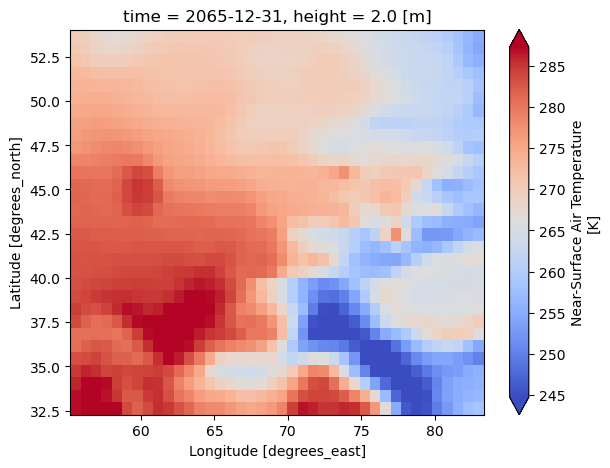

In [12]:
# get the first variable name
first_var = list(ds_1.data_vars)[0]

# select that variable and last timestep
da_1 = ds_1[first_var].isel(time=-1)


# da_1 = ds_1[0].isel(time =-1)


da_1.plot(cmap="coolwarm", robust=True, size=5)

# plt.title(str(da["valid_time"].values))  # extract timestamp from coords
# plt.savefig('ERA5_pr_1988-12-22_21UTC.png')
plt.show()

<xarray.Dataset> Size: 13MB
Dimensions:    (time: 2557, lat: 31, lon: 40, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 20kB 2059-01-01 2059-01-02 ... 2065-12-31
  * lat        (lat) float32 124B 53.69 52.98 52.28 51.58 ... 34.04 33.33 32.63
  * lon        (lon) float32 160B 55.55 56.25 56.95 57.66 ... 81.56 82.27 82.97
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 13MB 266.8 266.3 265.5 ... 257.6 258.4
    time_bnds  (time, bnds) datetime64[ns] 41kB 2058-12-31T12:00:00 ... 2065-...
    lat_bnds   (lat, bnds) float32 248B 54.03 53.33 53.33 ... 32.98 32.98 32.28
    lon_bnds   (lon, bnds) float32 320B 55.2 55.9 55.9 ... 82.62 82.62 83.32
Attributes: (12/45)
    Conventions:            CF-1.7
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time:            0.0
    branch_time_in_child:   60265.0D
    branch_time_in_parent:  60265.0D
    ...                    

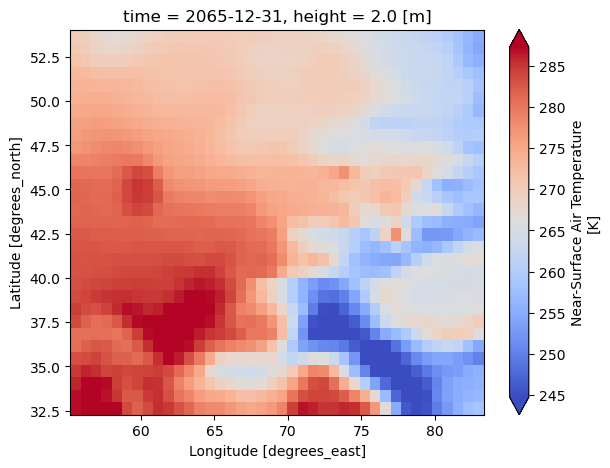

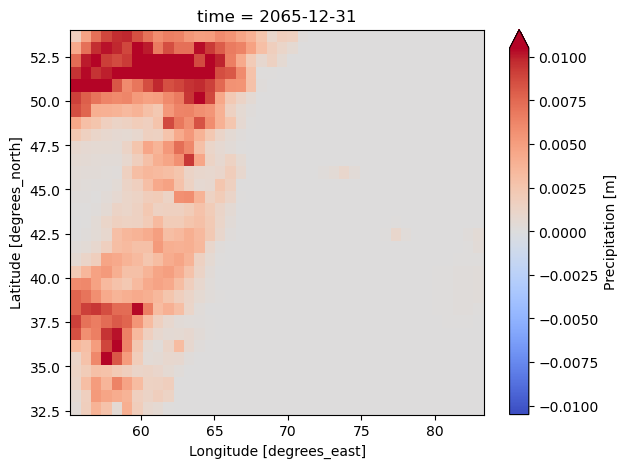

In [13]:
for file_name in [CMIP_forcing.temperatureNC, CMIP_forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{CMIP_forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)

In [2]:
ERA5_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script",
)

PCR_CMIP_Forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin/work/diagnostic/script",
)

PCR_CMIP_Forcing_regrid = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/Temp_storage_for_testing/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin/work/diagnostic/script",
)


from rich import print

print(ERA5_forcing)
print(PCR_CMIP_Forcing)
print(PCR_CMIP_Forcing_regrid)

PCRGlobWBForcing(
    start_time='1940-01-01T00:00:00Z',
    end_time='1960-12-31T00:00:00Z',
    directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script'),
    shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_pro
gress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'),
    filenames={},
    precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1960_AralSea_basin.nc',
    temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-1960_AralSea_basin.nc'
)

PCRGlobWBForcing(
    start_time='2060-01-01T00:00:00Z',
    end_time='2065-12-31T00:00:00Z',
    directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin/work/diagnostic/script')
,
    shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_pro
gress/forcing/output/PCRGLOBWB/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin/work/diagnostic/script/AralS
ea_basin.shp'),
    filenames={},
    precipitationNC='pcrglobwb_CMIP6_EC-Earth3_day_ssp585_r1i1p1f1_pr_gr_2060-2065_AralSea_basin.nc',
    temperatureNC='pcrglobwb_CMIP6_EC-Earth3_day_ssp585_r1i1p1f1_tas_gr_2060-2065_AralSea_basin.nc'
)

PCRGlobWBForcing(
    start_time='2060-01-01T00:00:00Z',
    end_time='2065-12-31T00:00:00Z',
    directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/Temp_storage_for_testing/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin
/work/diagnostic/script'),
    shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_pro
gress/forcing/output/PCRGLOBWB/Temp_storage_for_testing/CMIP6/EC-Earth3/ssp585/r1i1p1f1/2060-2065/AralSea_basin/wor
k/diagnostic/script/AralSea_basin.shp'),
    filenames={},
    precipitationNC='pcrglobwb_CMIP6_EC-Earth3_day_ssp585_r1i1p1f1_pr_gr_2060-2065_AralSea_basin.nc',
    temperatureNC='pcrglobwb_CMIP6_EC-Earth3_day_ssp585_r1i1p1f1_tas_gr_2060-2065_AralSea_basin.nc'
)

<xarray.Dataset> Size: 323MB
Dimensions:    (time: 8036, lat: 89, lon: 113, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 64kB 1939-01-01 1939-01-02 ... 1960-12-31
  * lat        (lat) float32 356B 54.0 53.75 53.5 53.25 ... 32.5 32.25 32.0
  * lon        (lon) float32 452B 55.0 55.25 55.5 55.75 ... 82.5 82.75 83.0
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 323MB 259.0 259.1 259.1 ... 260.7 260.8
    time_bnds  (time, bnds) datetime64[ns] 129kB 1938-12-31T12:00:00 ... 1960...
    lat_bnds   (lat, bnds) float32 712B 54.12 53.88 53.88 ... 32.12 32.12 31.88
    lon_bnds   (lon, bnds) float32 904B 54.88 55.12 55.12 ... 82.88 82.88 83.12
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the PCR-GLOBWB hydrological model.

------------------------

<xarray.Dataset> Size: 323MB
Dimensions:    (time: 8036, lat: 89, lon: 113, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 64kB 1939-01-01 1939-01-02 ... 1960-12-31
  * lat        (lat) float32 356B 54.0 53.75 53.5 53.25 ... 32.5 32.25 32.0
  * lon        (lon) float32 452B 55.0 55.25 55.5 55.75 ... 82.5 82.75 83.0
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 323MB 0.001428 0.001434 ... 0.0002871
    time_bnds  (time, bnds) datetime64[ns] 129kB 1938-12-31T12:00:00 ... 1960...
    lat_bnds   (lat, bnds) float32 712B 54.12 53.88 53.88 ... 32.12 32.12 31.88
    lon_bnds   (lon, bnds) float32 904B 54.88 55.12 55.12 ... 82.88 82.88 83.12
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the PCR-GLOBWB hydrological model.

------------------------

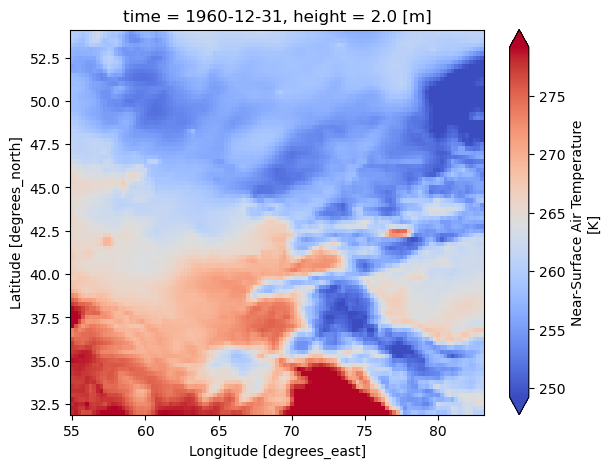

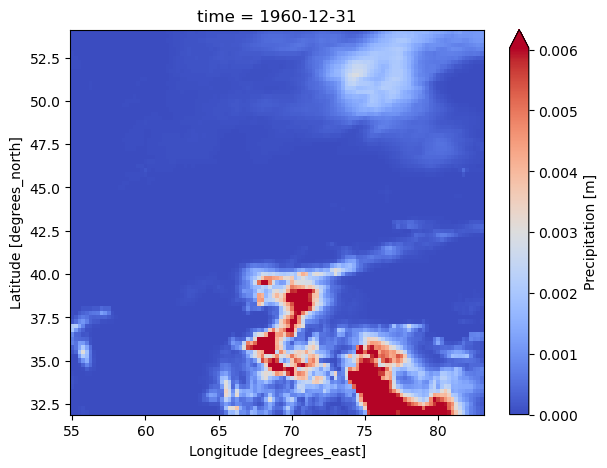

In [3]:
for file_name in [ERA5_forcing.temperatureNC, ERA5_forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{ERA5_forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)

In [4]:
regrid_pcrglobwb_forcing(PCR_CMIP_Forcing_regrid, ERA5_forcing)

<xarray.Dataset> Size: 103MB
Dimensions:  (time: 2557, lat: 89, lon: 113)
Coordinates:
  * time     (time) datetime64[ns] 20kB 2059-01-01 2059-01-02 ... 2065-12-31
    height   float64 8B 2.0
  * lat      (lat) float32 356B 54.0 53.75 53.5 53.25 ... 32.75 32.5 32.25 32.0
  * lon      (lon) float32 452B 55.0 55.25 55.5 55.75 ... 82.25 82.5 82.75 83.0
Data variables:
    tas      (time, lat, lon) float32 103MB 266.8 266.8 266.8 ... 258.4 258.4
Attributes: (12/48)
    regrid_method:          bilinear
    Conventions:            CF-1.7
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time:            0.0
    branch_time_in_child:   60265.0D
    ...                     ...
    title:                  EC-Earth3 output prepared for CMIP6
    variable_id:            tas
    variant_label:          r1i1p1f1
    caption:                Forcings for the PCR-GLOBWB hydrological model.
    regridded_to:           ERA5
    regridding_method:      bilinear

------------------------

<xarray.Dataset> Size: 103MB
Dimensions:  (time: 2557, lat: 89, lon: 113)
Coordinates:
  * time     (time) datetime64[ns] 20kB 2059-01-01 2059-01-02 ... 2065-12-31
  * lat      (lat) float32 356B 54.0 53.75 53.5 53.25 ... 32.75 32.5 32.25 32.0
  * lon      (lon) float32 452B 55.0 55.25 55.5 55.75 ... 82.25 82.5 82.75 83.0
Data variables:
    pr       (time, lat, lon) float32 103MB 0.002138 0.002138 ... -9.324e-24
Attributes: (12/48)
    regrid_method:          bilinear
    Conventions:            CF-1.7
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time:            0.0
    branch_time_in_child:   60265.0D
    ...                     ...
    title:                  EC-Earth3 output prepared for CMIP6
    variable_id:            pr
    variant_label:          r1i1p1f1
    caption:                Forcings for the PCR-GLOBWB hydrological model.
    regridded_to:           ERA5
    regridding_method:      bilinear

------------------------

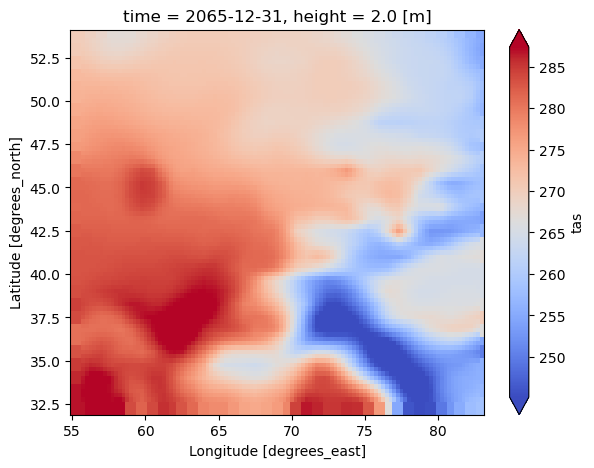

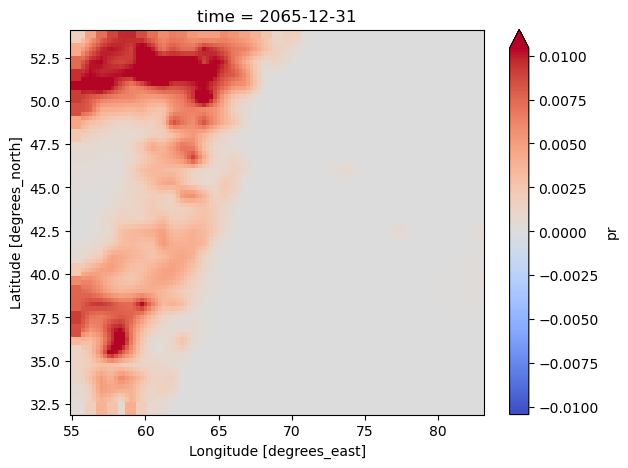

In [5]:
for file_name in [PCR_CMIP_Forcing_regrid.temperatureNC, PCR_CMIP_Forcing_regrid.precipitationNC]:
    dataset = xr.load_dataset(f"{PCR_CMIP_Forcing_regrid.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)

<xarray.Dataset> Size: 13MB
Dimensions:    (time: 2557, lat: 31, lon: 40, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 20kB 2059-01-01 2059-01-02 ... 2065-12-31
  * lat        (lat) float32 124B 53.69 52.98 52.28 51.58 ... 34.04 33.33 32.63
  * lon        (lon) float32 160B 55.55 56.25 56.95 57.66 ... 81.56 82.27 82.97
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 13MB 266.8 266.3 265.5 ... 257.6 258.4
    time_bnds  (time, bnds) datetime64[ns] 41kB 2058-12-31T12:00:00 ... 2065-...
    lat_bnds   (lat, bnds) float32 248B 54.03 53.33 53.33 ... 32.98 32.98 32.28
    lon_bnds   (lon, bnds) float32 320B 55.2 55.9 55.9 ... 82.62 82.62 83.32
Attributes: (12/45)
    Conventions:            CF-1.7
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time:            0.0
    branch_time_in_child:   60265.0D
    branch_time_in_parent:  60265.0D
    ...                     ...
    table_id:               day
    table_info:             Creation Date:(24 July 2019) MD5:70649eeb16bc90c4...
    title:                  EC-Earth3 output prepared for CMIP6
    variable_id:            tas
    variant_label:          r1i1p1f1
    caption:                Forcings for the PCR-GLOBWB hydrological model.

------------------------

<xarray.Dataset> Size: 13MB
Dimensions:    (time: 2557, lat: 31, lon: 40, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 20kB 2059-01-01 2059-01-02 ... 2065-12-31
  * lat        (lat) float32 124B 53.69 52.98 52.28 51.58 ... 34.04 33.33 32.63
  * lon        (lon) float32 160B 55.55 56.25 56.95 57.66 ... 81.56 82.27 82.97
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 13MB 0.002138 0.00202 ... -9.324e-24
    time_bnds  (time, bnds) datetime64[ns] 41kB 2058-12-31T12:00:00 ... 2065-...
    lat_bnds   (lat, bnds) float32 248B 54.03 53.33 53.33 ... 32.98 32.98 32.28
    lon_bnds   (lon, bnds) float32 320B 55.2 55.9 55.9 ... 82.62 82.62 83.32
Attributes: (12/45)
    Conventions:            CF-1.7
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time:            0.0
    branch_time_in_child:   60265.0D
    branch_time_in_parent:  60265.0D
    ...                     ...
    table_id:               day
    table_info:             Creation Date:(24 July 2019) MD5:70649eeb16bc90c4...
    title:                  EC-Earth3 output prepared for CMIP6
    variable_id:            pr
    variant_label:          r1i1p1f1
    caption:                Forcings for the PCR-GLOBWB hydrological model.

------------------------

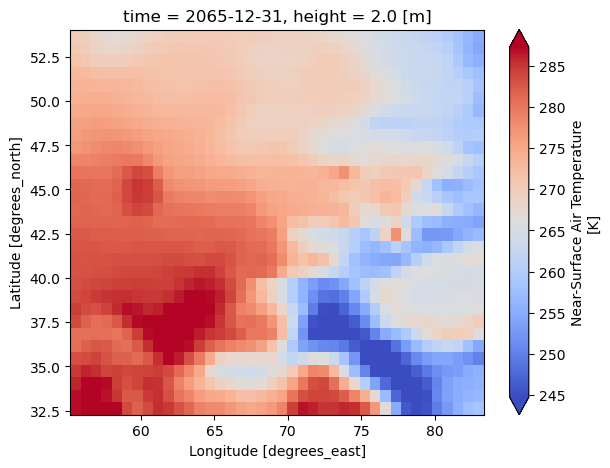

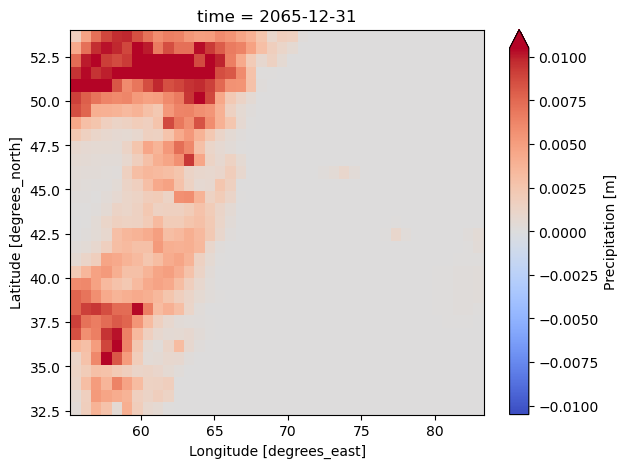

In [6]:
for file_name in [PCR_CMIP_Forcing.temperatureNC, PCR_CMIP_Forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{PCR_CMIP_Forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)